# FORGE — Benchmark Analysis

Reproduces every chart and number in this notebook from two small, committed
files — `results/sweep_summary.json` (135 aggregated cells from a real
2,511-request sweep across `mlx_lm`, `ollama`, and `vllm_metal`) and
`results/cost_model_results.json` (Phase 3's cost model output). Neither
requires re-running the actual sweep, the three servers it needs, or
identical Apple Silicon hardware — that's the point: cloning this repo and
running this notebook top to bottom reproduces the headline chart, not just
displays a screenshot of one.

The raw per-request data (`results/sweep/*.jsonl`) that these summaries were
built from is gitignored — regenerate it with `python -m forge.phase2.sweep`
if you want the full per-token timelines, then rebuild the summaries with
`python -m forge.phase5.build_summary`.

See [README.md](../README.md) for the full project, and
[docs/failure-gallery.md](../docs/failure-gallery.md) for what broke along
the way.


In [1]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sweep = json.loads((REPO_ROOT / "results" / "sweep_summary.json").read_text())
cost_model = json.loads((REPO_ROOT / "results" / "cost_model_results.json").read_text())

print(f"{len(sweep)} sweep cells, {len(cost_model['local_variants'])} cost-model rows")

135 sweep cells, 9 cost-model rows


## Headline finding: prefill is compute-bound, decode is memory-bound

This is the finding the whole project is built to surface, and the reason
every result in this repo reports TTFT and inter-token latency (ITL)
separately rather than blending them into one "latency" number. If they
scaled the same way, that separation would be pedantic. They don't:


TTFT p50 by bucket (ms): {'short': 99.2, 'medium': 134.8, 'long': 455.0}
ITL p50 by bucket (ms): {'short': 8.23, 'medium': 8.55, 'long': 9.15}


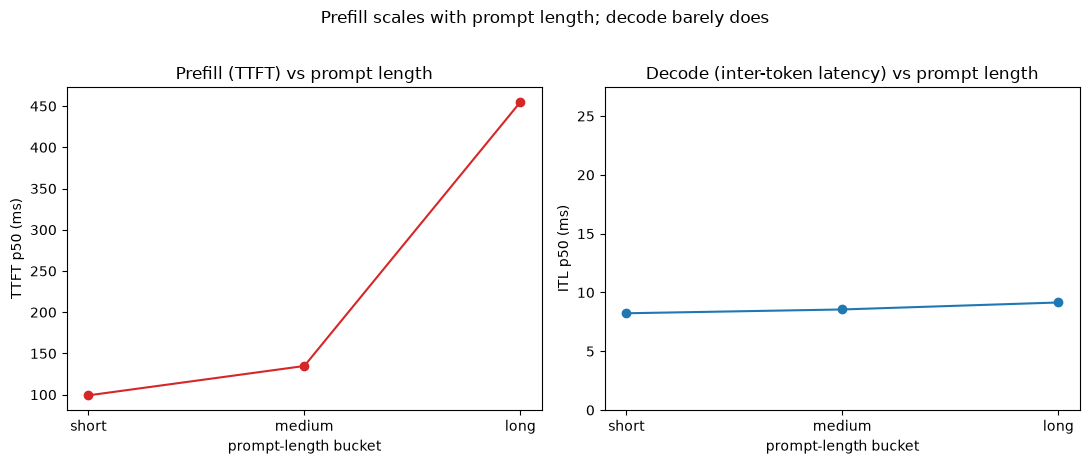

In [2]:
BUCKET_ORDER = ["short", "medium", "long"]

# TTFT at concurrency=1 (no batching interference), averaged across arms and
# quantization variants, per prompt-length bucket.
ttft_by_bucket = defaultdict(list)
itl_by_bucket = defaultdict(list)
for row in sweep:
    if row["concurrency"] != 1:
        continue
    if row["ttft_ms"]:
        ttft_by_bucket[row["prompt_bucket"]].append(row["ttft_ms"]["p50"])
    if row["inter_token_latency_ms"]:
        itl_by_bucket[row["prompt_bucket"]].append(row["inter_token_latency_ms"]["p50"])

ttft_avg = [sum(ttft_by_bucket[b]) / len(ttft_by_bucket[b]) for b in BUCKET_ORDER]
itl_avg = [sum(itl_by_bucket[b]) / len(itl_by_bucket[b]) for b in BUCKET_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(BUCKET_ORDER, ttft_avg, marker="o", color="tab:red")
axes[0].set_title("Prefill (TTFT) vs prompt length")
axes[0].set_ylabel("TTFT p50 (ms)")
axes[0].set_xlabel("prompt-length bucket")

axes[1].plot(BUCKET_ORDER, itl_avg, marker="o", color="tab:blue")
axes[1].set_title("Decode (inter-token latency) vs prompt length")
axes[1].set_ylabel("ITL p50 (ms)")
axes[1].set_xlabel("prompt-length bucket")
axes[1].set_ylim(0, max(itl_avg) * 3)  # same scale story as TTFT, not stretched to hide flatness

fig.suptitle("Prefill scales with prompt length; decode barely does", y=1.02)
fig.tight_layout()

ttft_rounded = [round(v, 1) for v in ttft_avg]
itl_rounded = [round(v, 2) for v in itl_avg]
print("TTFT p50 by bucket (ms):", dict(zip(BUCKET_ORDER, ttft_rounded, strict=True)))
print("ITL p50 by bucket (ms):", dict(zip(BUCKET_ORDER, itl_rounded, strict=True)))

Averaged across all three arms and all three quantization levels: **TTFT
rises roughly 4-5x from the short to the long bucket** (prefill has to
process ~15-45x more prompt tokens, and it shows), while **inter-token
latency moves less than 15%** across the same range. Once generation
starts, the cost of producing the *next* token barely depends on how long
the prompt was — it depends on memory bandwidth for repeatedly reading the
model's weights, which is why quantization (a smaller model in memory) and
concurrency (batching those reads across requests) are the levers that
actually move decode throughput, not prompt length.


## Plot 1 — TTFT vs prompt length, per arm

Same measurement as above, broken out per serving arm instead of averaged
together (still concurrency=1, still averaged across each arm's three
quantization variants).


mlx_lm {'short': 137.3, 'medium': 165.4, 'long': 649.4}
ollama {'short': 95.1, 'medium': 120.9, 'long': 640.8}
vllm_metal {'short': 65.1, 'medium': 118.1, 'long': 74.6}


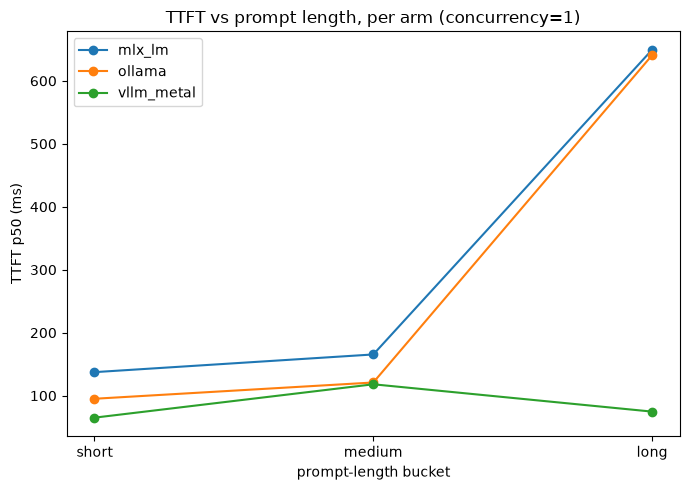

In [3]:
ttft_by_arm_bucket = defaultdict(list)
for row in sweep:
    if row["concurrency"] == 1 and row["ttft_ms"]:
        ttft_by_arm_bucket[(row["arm"], row["prompt_bucket"])].append(row["ttft_ms"]["p50"])

fig, ax = plt.subplots(figsize=(7, 5))
for arm in ["mlx_lm", "ollama", "vllm_metal"]:
    values = [
        sum(ttft_by_arm_bucket[(arm, b)]) / len(ttft_by_arm_bucket[(arm, b)]) for b in BUCKET_ORDER
    ]
    ax.plot(BUCKET_ORDER, values, marker="o", label=arm)
    rounded = [round(v, 1) for v in values]
    print(arm, dict(zip(BUCKET_ORDER, rounded, strict=True)))

ax.set_ylabel("TTFT p50 (ms)")
ax.set_xlabel("prompt-length bucket")
ax.set_title("TTFT vs prompt length, per arm (concurrency=1)")
ax.legend()
fig.tight_layout()

`mlx_lm` and `ollama` both scale monotonically with prompt length, as
expected for compute-bound prefill. `vllm_metal`'s long-bucket TTFT comes in
*below* its medium-bucket TTFT — the opposite of the other two arms. Two
honest candidate explanations, not adjudicated here: (a) each cell is only
3 requests at concurrency=1, so this could simply be noise; (b) vllm-metal
documents automatic prefix-cache reuse as its *default* behavior for unified
paged-KV models (see `docs/supported_models.md` in the vllm-metal repo) —
since every case in a bucket shares a large common schema prefix, a warmed
prefix cache would let vllm_metal skip re-prefilling most of a long prompt
on later requests, specifically shrinking its long-bucket number. Both are
plausible; this data alone doesn't distinguish them, and it would take a
targeted repeat-count experiment to say which one is real.


## Plot 2 — Throughput vs concurrency, per arm

Medium bucket (matches the model's own training-prompt shape), each arm's
fastest quantization variant at concurrency=8 — same "fastest per arm"
convention `forge.phase3.build_report` uses for its own chart, so this
isn't a second, differently-chosen comparison.


mlx_lm 4bit {1: 116.2, 2: 134.4, 4: 148.1, 8: 154.9, 16: 157.7}
ollama q4 {1: 103.4, 2: 139.4, 4: 147.1, 8: 151.7, 16: 164.7}
vllm_metal 4bit {1: 191.6, 2: 249.3, 4: 365.1, 8: 459.8, 16: 581.0}


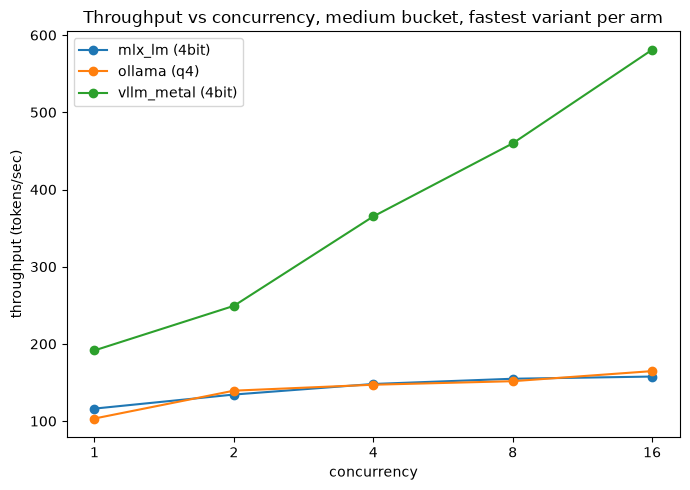

In [4]:
MEDIUM = "medium"
throughput_by_arm_variant_c8 = {}
for row in sweep:
    is_target_cell = row["prompt_bucket"] == MEDIUM and row["concurrency"] == 8
    if is_target_cell and row["throughput_tokens_per_sec"]:
        key = (row["arm"], row["model_variant"])
        throughput_by_arm_variant_c8[key] = row["throughput_tokens_per_sec"]

fastest_variant = {}
for (arm, variant), tput in throughput_by_arm_variant_c8.items():
    current_best = throughput_by_arm_variant_c8.get((arm, fastest_variant.get(arm)))
    if current_best is None or tput > current_best:
        fastest_variant[arm] = variant

fig, ax = plt.subplots(figsize=(7, 5))
concurrencies = [1, 2, 4, 8, 16]
for arm, variant in fastest_variant.items():
    values = []
    for c in concurrencies:
        match = [
            r["throughput_tokens_per_sec"]
            for r in sweep
            if r["arm"] == arm
            and r["model_variant"] == variant
            and r["prompt_bucket"] == MEDIUM
            and r["concurrency"] == c
        ]
        values.append(match[0] if match else None)
    ax.plot(concurrencies, values, marker="o", label=f"{arm} ({variant})")
    rounded = [round(v, 1) if v else None for v in values]
    print(arm, variant, dict(zip(concurrencies, rounded, strict=True)))

ax.set_xscale("log", base=2)
ax.set_xticks(concurrencies)
ax.set_xticklabels(concurrencies)
ax.set_xlabel("concurrency")
ax.set_ylabel("throughput (tokens/sec)")
ax.set_title("Throughput vs concurrency, medium bucket, fastest variant per arm")
ax.legend()
fig.tight_layout()

There's no crossover here — `vllm_metal` is fastest at every concurrency
level tested, including concurrency=1. What batching actually buys is a
**widening gap**: from concurrency 1 to 16, `vllm_metal` scales throughput
roughly **3.0x** (continuous batching doing what it's designed to do),
while `mlx_lm` scales only about **1.4x** and `ollama` about **1.6x** over
the same range. The plan this project started from expected to find a
concurrency threshold where one arm "overtakes" another — the real finding
is more specific than that: the ranking never changes, but the *cost of
picking the slower arm* grows severalfold as concurrency rises, which
matters more for a production capacity-planning decision than a one-time
crossover point would have.


## Plot 3 — Accuracy vs cost-per-1k-queries, per quantization level

From Phase 3's cost model, at its stated representative volume (10,000
queries/month) and prompt bucket (medium — matches the model's own
training-prompt shape).


cost-per-1k range across all 9 variants: ₹694.19 - ₹694.28


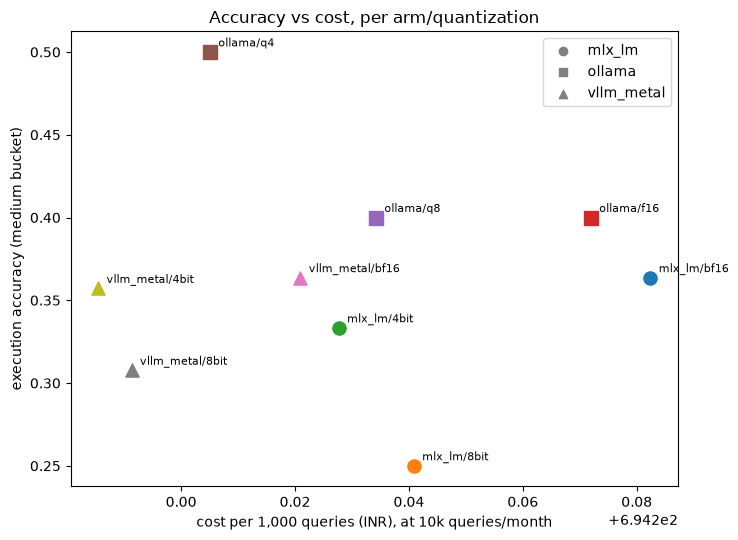

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
markers = {"mlx_lm": "o", "ollama": "s", "vllm_metal": "^"}
for row in cost_model["local_variants"]:
    if row["execution_accuracy"] is None:
        continue
    cost_per_1k = row["cost_per_query_inr_at_10k_monthly"] * 1000
    ax.scatter(cost_per_1k, row["execution_accuracy"], marker=markers[row["arm"]], s=90, label=None)
    ax.annotate(
        f"{row['arm']}/{row['variant']}",
        (cost_per_1k, row["execution_accuracy"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )

for arm, marker in markers.items():
    ax.scatter([], [], marker=marker, color="gray", label=arm)  # legend entries only

ax.set_xlabel("cost per 1,000 queries (INR), at 10k queries/month")
ax.set_ylabel("execution accuracy (medium bucket)")
ax.set_title("Accuracy vs cost, per arm/quantization")
ax.legend()
fig.tight_layout()

costs = [r["cost_per_query_inr_at_10k_monthly"] * 1000 for r in cost_model["local_variants"]]
print(f"cost-per-1k range across all 9 variants: ₹{min(costs):.2f} - ₹{max(costs):.2f}")

The points are nearly stacked vertically — at 10,000 queries/month, cost
per query is **within about 9 paise of itself across every variant
regardless of quantization or throughput** (`docs/cost-model.md` has the
exact figures).
That's a real, if slightly anticlimactic, finding, not a plotting artifact:
at this volume every configuration is running at well under 10% of the
machine's lifetime throughput capacity, so cost is dominated entirely by
fixed hardware amortization — throughput differences between quantization
levels don't show up as a lower cost-per-query until volume approaches the
machine's actual capacity ceiling (see the break-even curve in
`docs/cost-model.md` for that volume-dependent view). Quantization's real
payoff in this cost model is raising that ceiling — the *sustainable*
volume before another machine is needed — not cutting cost at typical
modest volumes. Accuracy, meanwhile, varies far more (0.25-0.36 across
these nine variants) for essentially the same cost, which is the actual
trade-off worth making a decision on here.


## What broke along the way

Zero request failures and zero recorded thermal-throttling events across
all 2,511 real requests in this sweep — the hardware-failure modes this
project's own plan anticipated (OOM, thermal throttling, a model vllm-metal
refuses to load) simply didn't happen on this machine. That's a real
result, not an omission: see
[docs/failure-gallery.md](../docs/failure-gallery.md) for what *did* go
wrong — a 100%-reproducible accuracy cliff, a malformed model output caught
in the deployed demo, and the real software bugs found and fixed at every
phase of building this.
